## Imports

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import LocalOutlierFactor

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.io import loadmat
from sklearn.metrics import roc_auc_score

from torch_geometric.nn import GCNConv
from torch_geometric.utils.convert import from_scipy_sparse_matrix

## Ex 1

### Ex 1.1

In [2]:
G = nx.Graph()

file_path = "ca-AstroPh.txt"

with open(file_path, "r") as f:
    for i, line in enumerate(f):
        if i >= 1500: # limit to first 1500 lines
            break
        u,v = map(int, line.strip().split())
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
        else:
            G.add_edge(u, v, weight=1)

### Ex 1.2

In [5]:
# 4 features from egonet

Ni = {}
Ei = {}
Wi = {}
lambda_wi = {}

for node in G.nodes():
    ego = nx.ego_graph(G, node, radius=1)
    
    Ni[node] = ego.number_of_nodes() - 1
    Ei[node] = ego.number_of_edges()
    Wi[node] = sum(d["weight"] for u, v, d in ego.edges(data=True))
    
    if ego.number_of_nodes() > 1:
        adjancy_matrix = nx.to_numpy_array(ego, weight="weight")
        eigenvalues = np.linalg.eigvals(adjancy_matrix)
        lambda_wi[node] = np.max(np.real(eigenvalues))
    else:
        lambda_wi[node] = 0

nx.set_node_attributes(G, Ni, "Ni")
nx.set_node_attributes(G, Ei, "Ei")
nx.set_node_attributes(G, Wi, "Wi")
nx.set_node_attributes(G, lambda_wi, "lambda_wi")

### Ex 1.3

In [6]:
X = np.array([Ni[n] for n in G.nodes()]).reshape(-1, 1)
y = np.array([Ei[n] for n in G.nodes()])

X_log = np.log(X + 1)
y_log = np.log(y + 1)

model = LinearRegression()
model.fit(X_log, y_log)

theta = model.coef_[0]
C = np.exp(model.intercept_)

scores = {}

for n in G.nodes():
    x = Ni[n]
    y_true = Ei[n]
    y_pred = C * (x ** theta)
    
    if min(y_true, y_pred) > 0:
        ratio = max(y_true, y_pred) / min(y_true, y_pred)
    else:
        ratio = 0
    
    score = ratio * np.log(abs(y_true - y_pred) + 1)
    
    scores[n] = score

### Ex 1.4

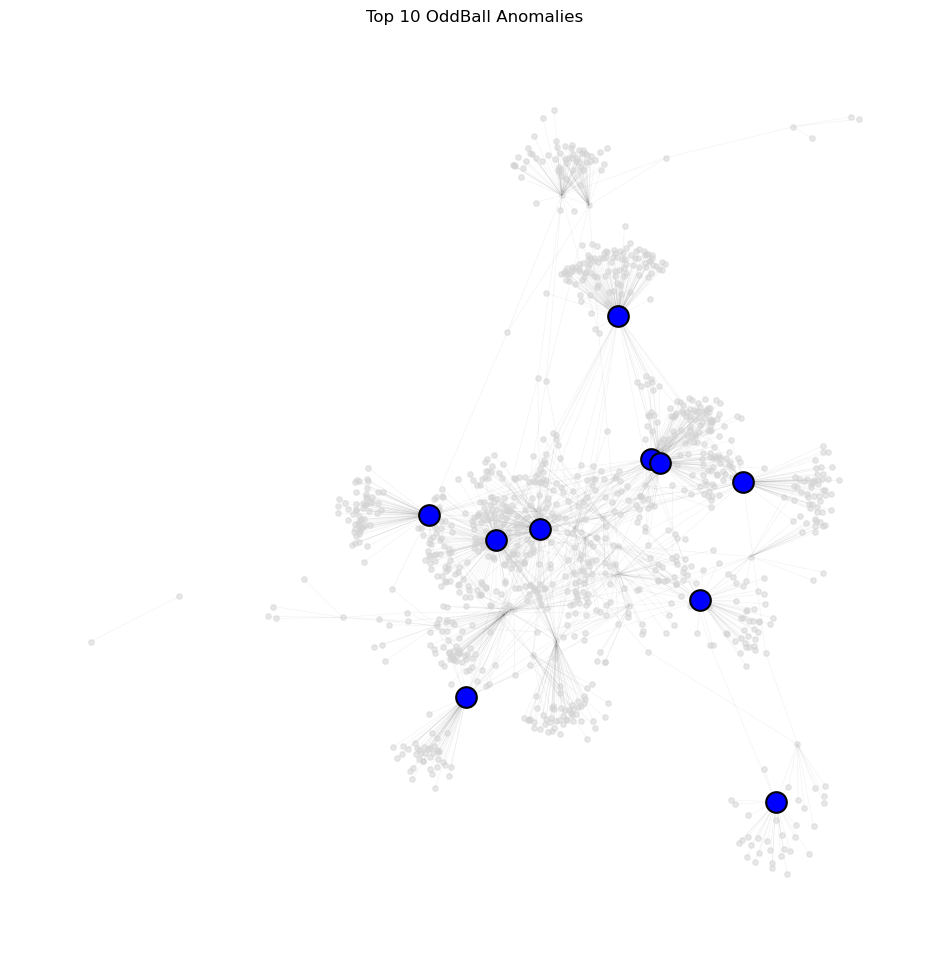

In [8]:
pos = nx.spring_layout(G, seed=23)

top10 = sorted(scores, key=scores.get, reverse=True)[:10]
normal_nodes = [n for n in G.nodes() if n not in top10]

plt.figure(figsize=(12, 12))

nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.5)

nx.draw_networkx_nodes(G, pos,nodelist=normal_nodes,node_color="lightgray",node_size=15,alpha=0.5)
nx.draw_networkx_nodes(G, pos,nodelist=top10,node_color="blue",node_size=220,edgecolors="black",linewidths=1.5)

plt.title("Top 10 OddBall Anomalies")
plt.axis("off")
plt.show()

### Ex 1.5

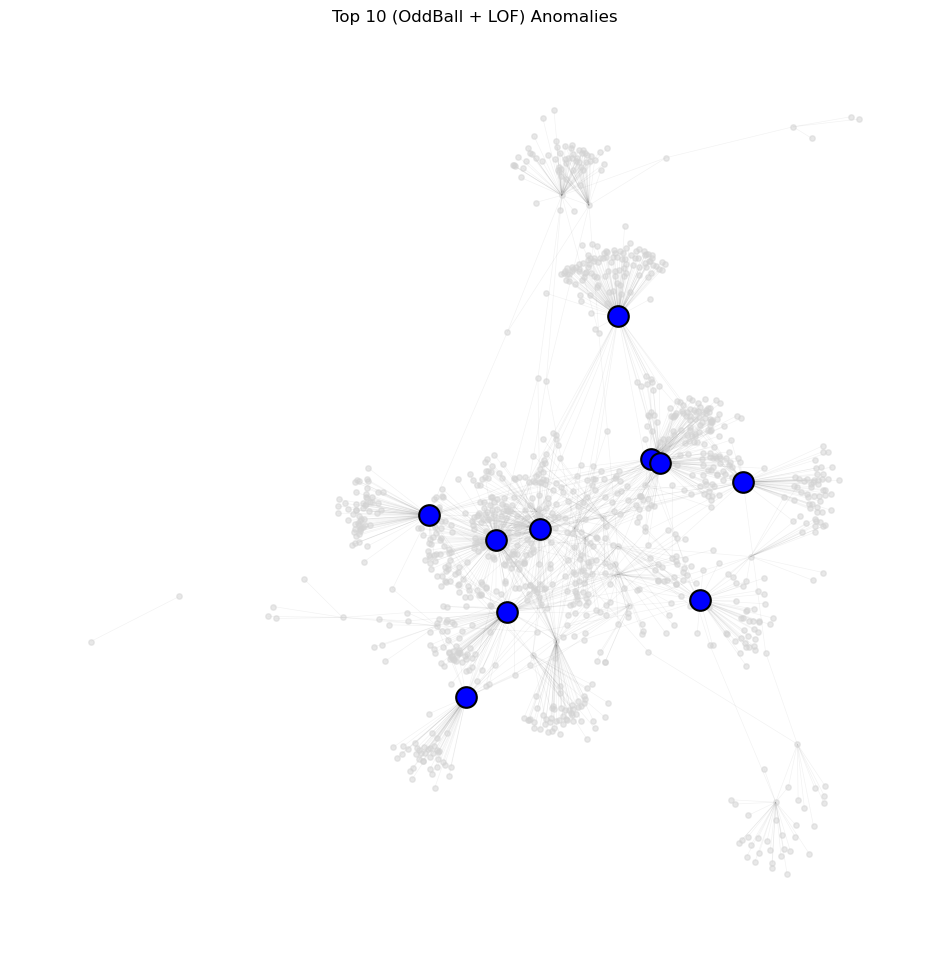

In [15]:
X_lof = np.array([[Ei[n], Ni[n]] for n in G.nodes()])

lof = LocalOutlierFactor(n_neighbors=800)
lof.fit_predict(X_lof)
lof_scores = -lof.negative_outlier_factor_

odd_scores = np.array(list(scores.values()))
odd_norm = (odd_scores - odd_scores.min()) / (odd_scores.max() - odd_scores.min())
lof_norm = (lof_scores - lof_scores.min()) / (lof_scores.max() - lof_scores.min())

combined_score = odd_norm + lof_norm # Combined score

nodes = list(G.nodes())
top10_combined = [nodes[i] for i in np.argsort(combined_score)[-10:]]
normal_nodes = [n for n in G.nodes() if n not in top10_combined]

plt.figure(figsize=(12, 12))

nx.draw_networkx_edges(G, pos, alpha=0.05, width=0.5)

nx.draw_networkx_nodes(G, pos,nodelist=normal_nodes,node_color="lightgray",node_size=15,alpha=0.5)

nx.draw_networkx_nodes(G, pos,nodelist=top10_combined,node_color="blue",node_size=220,edgecolors="black",linewidths=1.5)

plt.title("Top 10 (OddBall + LOF) Anomalies")
plt.axis("off")
plt.show()

## Ex 2

### Ex 2.1

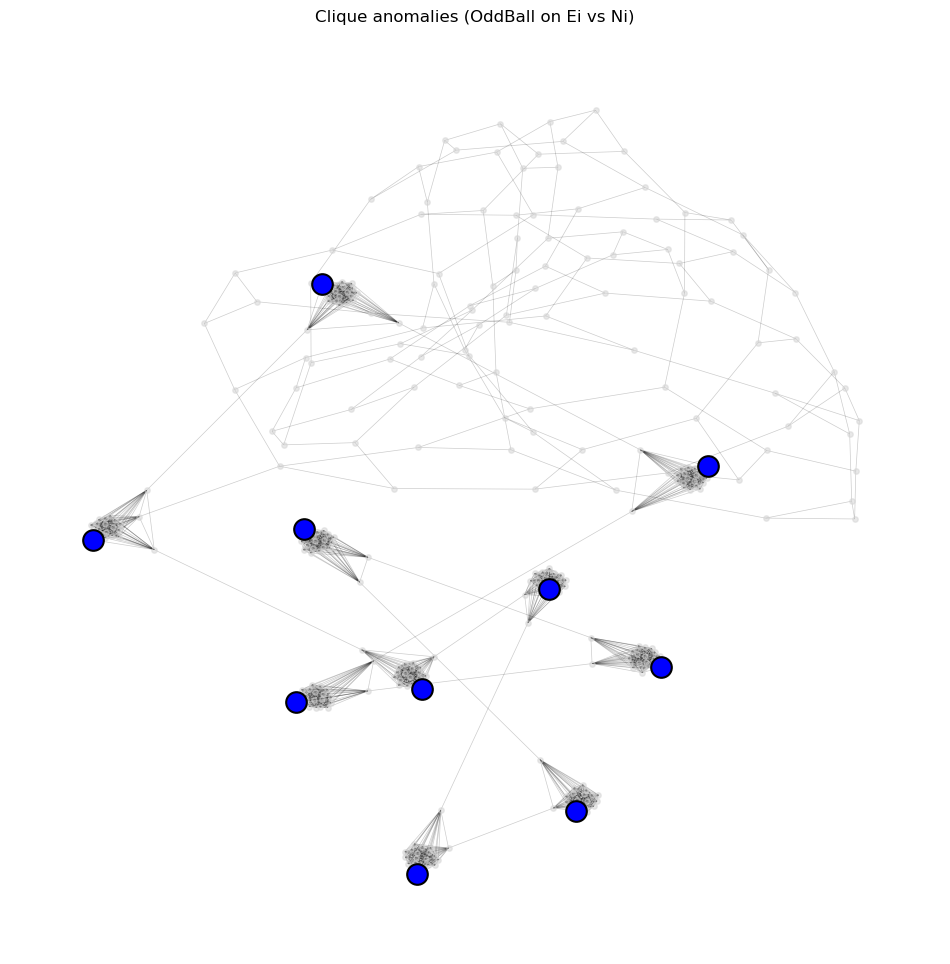

Top 10 anomalies: ['C1', 'C21', 'C41', 'C61', 'C81', 'C101', 'C121', 'C141', 'C161', 'C181']
Clique nodes in top10: 10 / 10


In [18]:
np.random.seed(23)

G_reg = nx.random_regular_graph(d=3, n=100, seed=42)
G_cliques = nx.connected_caveman_graph(l=10, k=20)

G = nx.union(G_reg, G_cliques, rename=("R", "C"))

#Connect components
components = list(nx.connected_components(G))
for i in range(len(components) - 1):
    u = np.random.choice(list(components[i]))
    v = np.random.choice(list(components[i + 1]))
    G.add_edge(u, v)

#Compute egonet features like in previous exercise
Ni, Ei = {}, {}
for n in G.nodes():
    ego = nx.ego_graph(G, n, radius=1)
    Ni[n] = ego.number_of_nodes() - 1
    Ei[n] = ego.number_of_edges()

nodes = list(G.nodes())
X = np.array([Ni[n] for n in nodes]).reshape(-1, 1)
y = np.array([Ei[n] for n in nodes])

X_log = np.log(X + 1)
y_log = np.log(y + 1)

model = LinearRegression()
model.fit(X_log, y_log)

theta = model.coef_[0]
C = np.exp(model.intercept_)

#OddBall anomaly scores
scores = {}

for n in nodes:
    x = Ni[n]
    y_true = Ei[n]
    y_pred = C * (x ** theta)
    
    if min(y_true, y_pred) > 0:
        ratio = max(y_true, y_pred) / min(y_true, y_pred)
    else:
        ratio = 0
    
    score = ratio * np.log(abs(y_true - y_pred) + 1)
    
    scores[n] = score

top10 = sorted(scores, key=scores.get, reverse=True)[:10]

#Visualization
pos = nx.spring_layout(G, seed=23)
normal_nodes = [n for n in nodes if n not in top10]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=normal_nodes, node_color="lightgray", node_size=15, alpha=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=top10, node_color="blue", node_size=220,edgecolors="black", linewidths=1.5)

plt.title("Clique anomalies (OddBall on Ei vs Ni)")
plt.axis("off")
plt.show()

print("Top 10 anomalies:", top10)
print("Clique nodes in top10:", sum(str(n).startswith("C") for n in top10), "/ 10")


### Ex 2.2

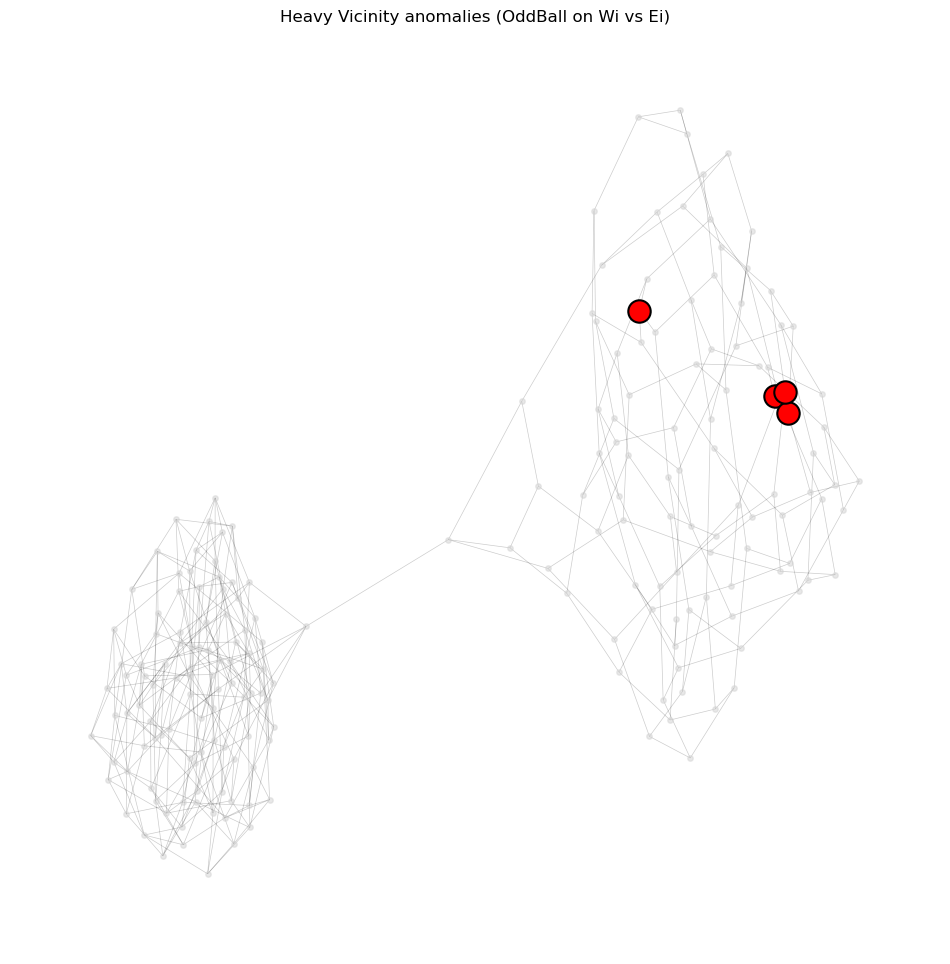

Injected anomaly centers: [np.str_('A_83'), np.str_('A_77')]
Top 4 detected anomalies: ['A_77', 'A_83', 'A_24', 'A_27']


In [ ]:
np.random.seed(23)

G1 = nx.random_regular_graph(d=3, n=100, seed=23)
G2 = nx.random_regular_graph(d=5, n=100, seed=23)

G = nx.union(G1, G2, rename=("A_", "B_"))

for u, v in G.edges():
    G[u][v]["weight"] = 1

# Connect components
components = list(nx.connected_components(G))
for i in range(len(components) - 1):
    u = np.random.choice(list(components[i]))
    v = np.random.choice(list(components[i + 1]))
    G.add_edge(u, v, weight=1)


anomaly_centers = list(np.random.choice(list(G.nodes()), size=2, replace=False))

for center in anomaly_centers:
    ego = nx.ego_graph(G, center, radius=1)
    for u, v in ego.edges():
        G[u][v]["weight"] += 10


Ei, Wi = {}, {}
for n in G.nodes():
    ego = nx.ego_graph(G, n, radius=1)
    Ei[n] = ego.number_of_edges()
    Wi[n] = sum(d["weight"] for _, _, d in ego.edges(data=True))


nodes = list(G.nodes())
X = np.array([Ei[n] for n in nodes]).reshape(-1, 1)
y = np.array([Wi[n] for n in nodes])

X_log = np.log(X + 1)
y_log = np.log(y + 1)

model = LinearRegression()
model.fit(X_log, y_log)

theta = model.coef_[0]
C = np.exp(model.intercept_)

scores = {}
for n in nodes:
    x = Ei[n]
    y_true = Wi[n]
    y_pred = C * (x ** theta)
    if min(y_true, y_pred) > 0:
        ratio = max(y_true, y_pred) / min(y_true, y_pred)
    else:
        ratio = 0
    
    score = ratio * np.log(abs(y_true - y_pred) + 1)

    scores[n] = score

top4 = sorted(scores, key=scores.get, reverse=True)[:4]

#Visualization
pos = nx.spring_layout(G, seed=23)
normal_nodes = [n for n in nodes if n not in top4]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=normal_nodes, node_color="lightgray", node_size=15, alpha=0.5)
nx.draw_networkx_nodes(G, pos, nodelist=top4, node_color="red", node_size=260,edgecolors="black", linewidths=1.5)

plt.title("Heavy Vicinity anomalies (OddBall on Wi vs Ei)")
plt.axis("off")
plt.show()

print("Injected anomaly centers:", anomaly_centers)
print("Top 4 detected anomalies:", top4)


## Ex 3

### Ex 3.1

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### Ex 3.2

In [24]:
mat = loadmat("ACM.mat")  

X_sp = mat["Attributes"]  
adjancy_matrix_sp = mat["Network"]     
labels = mat["Label"]    

X = X_sp.toarray()
X = torch.tensor(X, dtype=torch.float32, device=device)

edge_index, edge_weight = from_scipy_sparse_matrix(adjancy_matrix_sp)
edge_index = edge_index.to(device)

A_dense = adjancy_matrix_sp.toarray()
A_dense = (A_dense > 0).astype(np.float32)  # binarize
A = torch.tensor(A_dense, dtype=torch.float32, device=device)

labels = np.array(labels).reshape(-1)
unique_labels = np.unique(labels)
print("Unique labels in dataset:", unique_labels)

y_true = (labels != unique_labels.min()).astype(int) 
y_true = torch.tensor(y_true, dtype=torch.long, device=device)

print("X shape:", tuple(X.shape))
print("A shape:", tuple(A.shape))
print("edge_index shape:", tuple(edge_index.shape))
print("y_true shape:", tuple(y_true.shape))


Unique labels in dataset: [0 1]
X shape: (16484, 8337)
A shape: (16484, 16484)
edge_index shape: (2, 164350)
y_true shape: (16484,)


### Ex 3.3

In [25]:
class Encoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gcn1 = GCNConv(dim, 128)
        self.gcn2 = GCNConv(128, 64)

    def forward(self, x, edge_index):
        x1 = F.relu(self.gcn1(x, edge_index))
        x2 = F.relu(self.gcn2(x1, edge_index))
        return x2


class AttrDecoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gcn1 = GCNConv(64, 128)
        self.gcn2 = GCNConv(128, dim)

    def forward(self, x2, edge_index):
        x1 = F.relu(self.gcn1(x2, edge_index))
        x_hat = F.relu(self.gcn2(x1, edge_index))
        return x_hat


class StructDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn = GCNConv(64, 64)

    def forward(self, x2, edge_index):
        h = F.relu(self.gcn(x2, edge_index))
        a_hat = h @ h.T
        return a_hat


class GraphAutoencoder(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.encoder = Encoder(dim)
        self.attr_decoder = AttrDecoder(dim)
        self.struct_decoder = StructDecoder()

    def forward(self, x, edge_index):
        x2 = self.encoder(x, edge_index)
        x_hat = self.attr_decoder(x2, edge_index)
        a_hat = self.struct_decoder(x2, edge_index)
        return x_hat, a_hat


gae = GraphAutoencoder(dim=X.shape[1]).to(device)
print(gae)


GraphAutoencoder(
  (encoder): Encoder(
    (gcn1): GCNConv(8337, 128)
    (gcn2): GCNConv(128, 64)
  )
  (attr_decoder): AttrDecoder(
    (gcn1): GCNConv(64, 128)
    (gcn2): GCNConv(128, 8337)
  )
  (struct_decoder): StructDecoder(
    (gcn): GCNConv(64, 64)
  )
)


### Ex 3.4

In [27]:
def gae_loss(X, X_hat, A, A_hat, alpha=0.8):
    attr_term = torch.norm(X - X_hat, p="fro") ** 2
    struct_term = torch.norm(A - A_hat, p="fro") ** 2
    return alpha * attr_term + (1 - alpha) * struct_term

optimizer = torch.optim.Adam(gae.parameters(), lr=0.004)
alpha = 0.8
print("alpha =", alpha, "/ lr = 0.004")

alpha = 0.8 / lr = 0.004


### Ex 3.5

In [28]:
epochs = 50

for epoch in range(1, epochs + 1):
    gae.train()
    optimizer.zero_grad()

    X_hat, A_hat = gae(X, edge_index)
    loss = gae_loss(X, X_hat, A, A_hat, alpha=alpha)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        gae.eval()
        with torch.no_grad():
            X_hat, A_hat = gae(X, edge_index)

            attr_err = ((X - X_hat) ** 2).sum(dim=1)
            struct_err = ((A - A_hat) ** 2).sum(dim=1) 
            scores = alpha * attr_err + (1 - alpha) * struct_err
            scores_np = scores.detach().cpu().numpy()

            y_np = y_true.detach().cpu().numpy()

            # ROC AUC
            auc = roc_auc_score(y_np, scores_np)

        print(f"Epoch {epoch:02d} / Loss: {loss.item():.4f} / ROC AUC: {auc:.4f}")

Epoch 01 / Loss: 39767.4492 / ROC AUC: 0.7498
Epoch 05 / Loss: 39728.6680 / ROC AUC: 0.8258
Epoch 10 / Loss: 39724.4648 / ROC AUC: 0.8258
Epoch 15 / Loss: 39723.7500 / ROC AUC: 0.8258
Epoch 20 / Loss: 39719.9766 / ROC AUC: 0.8258
Epoch 25 / Loss: 39713.4766 / ROC AUC: 0.8258
Epoch 30 / Loss: 39706.9727 / ROC AUC: 0.8258
Epoch 35 / Loss: 39697.1836 / ROC AUC: 0.8258
Epoch 40 / Loss: 39681.2539 / ROC AUC: 0.8259
Epoch 45 / Loss: 39663.3203 / ROC AUC: 0.8260
Epoch 50 / Loss: 39647.3789 / ROC AUC: 0.8260
